### Import thư viện cần thiết

In [253]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

### Phân tích và tiền xử lí dữ liệu 
- Kiểm tra các thuộc tính (kiểu dữ liệu, có bị NULL không)
- chuẩn hóa tháng 
- chuẩn hóa ngày

In [254]:
df = pd.read_csv('C:\\Users\\nguye\\DS102\\Lab01\\forestfires.csv')

In [255]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [256]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [257]:
df.head(10)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0
5,8,6,aug,sun,92.3,85.3,488.0,14.7,22.2,29,5.4,0.0,0.0
6,8,6,aug,mon,92.3,88.9,495.6,8.5,24.1,27,3.1,0.0,0.0
7,8,6,aug,mon,91.5,145.4,608.2,10.7,8.0,86,2.2,0.0,0.0
8,8,6,sep,tue,91.0,129.5,692.6,7.0,13.1,63,5.4,0.0,0.0
9,7,5,sep,sat,92.5,88.0,698.6,7.1,22.8,40,4.0,0.0,0.0


In [258]:
df['month'] = df['month'].map({'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6, 'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12})
df['day'] = df['day'].map({'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun': 7})

In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    int64  
 3   day     517 non-null    int64  
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(5)
memory usage: 52.6 KB


### Chia tập train, test và đưa về kiểu dữ liệu numpy 

In [260]:
def Create_Data(df):
    X = df.drop('area', axis=1)
    y = df['area']
    X = X.to_numpy()
    y = y.to_numpy()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)
    return X_train, X_test, y_train, y_test

In [261]:
X_train, X_test, y_train, y_test = Create_Data(df)

### Assignment 1 (3 scores):
- Use the Numpy library only to construct the Linear Regression model.
- Train and Evaluate that Linear Regression model on the [Forest Fires]

### Xây dựng lớp mô hình Linear regression

In [262]:
class QuanLinearRegression:
    def __init__(self, bias=True):
        self.bias = bias
        self.theta = None

    def Add_Bias(self, X):
        Bias = np.ones((X.shape[0], 1))
        return np.concatenate((Bias, X), axis=1)

    def fit(self, X, y):
        X_train = self.Add_Bias(X) if self.bias else X
        self.theta = np.linalg.pinv(X_train.T.dot(X_train)).dot(X_train.T).dot(y)
        return self

    def predict(self, X):
        X_test = self.Add_Bias(X) if self.bias else X
        return X_test.dot(self.theta)

    def rmse(self, y_true, y_pred):
        return np.sqrt(np.mean((y_true - y_pred)**2))

### Đánh giá mô hình 

In [263]:
model = QuanLinearRegression(bias=True)
model.fit(X_train, y_train) 
y_pred = model.predict(X_test)
rmse_task1 = model.rmse(y_test, y_pred)     
print(f"RMSE: {rmse_task1}")

RMSE: 26.247071899179602


### Nhận xét: mô hình còn sai số khá cao, vẫn phải tiếp tục tinh chỉnh 

### Assignment 2 (3 scores):
- Standardize the data so that their mean is 0 and their variance is 1.
- Compare the results of Linear Regression model when being trained on the original and standardized data.

### Chuẩn hóa dữ liệu về mean = 0 và var = 1

In [264]:
for col in df.columns:
        if(col != 'area'):
            df[col] = (df[col] - df[col].mean()) / df[col].std()

### So sánh mô hình sau khi chuẩn hóa dữ liệu và mô hình chưa chuẩn hóa 

In [265]:
X_train, X_test, y_train, y_test = Create_Data(df)
model = QuanLinearRegression(bias=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse_task2 = model.rmse(y_test, y_pred)
print(f"RMSE: {rmse_task2}")

RMSE: 26.247071899125963


In [266]:
diff = rmse_task1 - rmse_task2
print(f"Chênh lệch RMSE: {diff:.10e}")

Chênh lệch RMSE: 5.3638871123e-11


### Nhận xét 
Có thể thấy chênh lệch về loss giữa 2 mô hình linear regression được huấn luyện trên 1 tập đã chuẩn hóa và 1 tập chưa chuẩn hóa được coi là như nhau và ta có thể đưa ra 2 nhận xét sau: 
- Do code của ta đã sử dụng theta là nghiệm tối ưu loss toàn cục duy nhất, nên việc chuẩn hóa thang đo không có tác dụng cải thiện độ chính xác, vì chuẩn hóa thang đo thì nghiệm toàn cục theta cũng sẽ tự động điều chỉnh kết quả dự báo giữ nguyên 
- còn về việc sai số > 0, về mặt thống kê ta có thể coi nó bằng 0, vì bản chất sai số này xuất hiện là do hiện tượng floating point phát sinh trong quá trình nhân các ma trận 


### Assignment 3 (2 scores):

- Perform feature engineering to remove columns that are linearly dependent (colinear) with other columns in the dataset.
- Evaluate the Linear Regression model when beeing trained on the original data and preprocessed data.

### Vẽ ma trận tương quan và xóa thuộc tính phụ thuộc tuyến tính

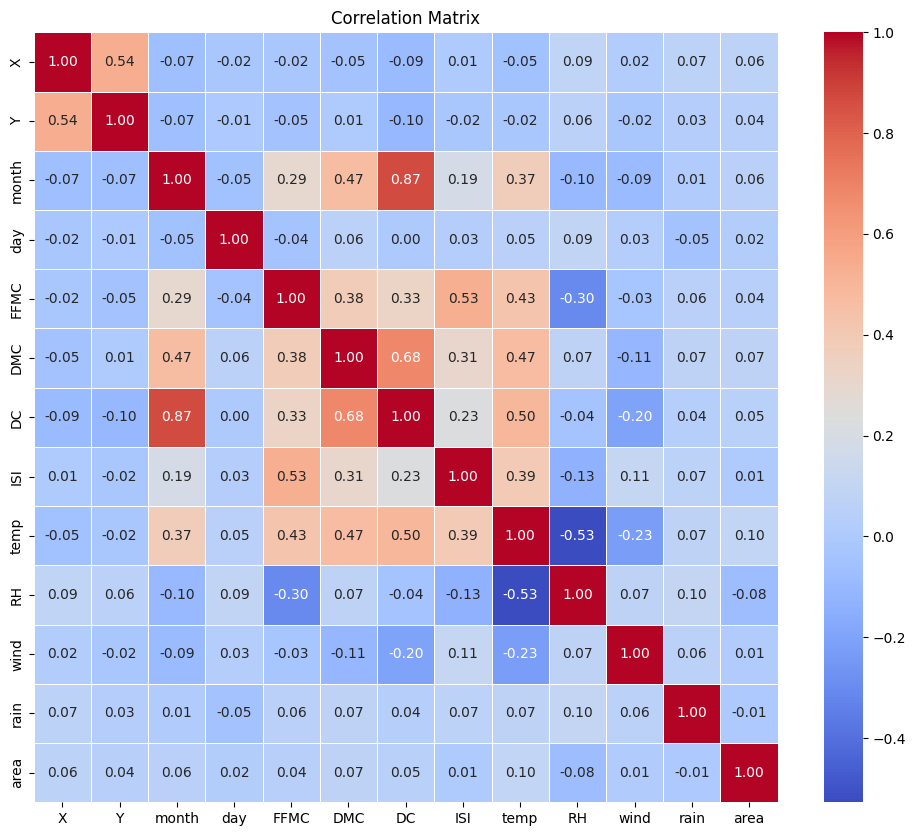

In [267]:
df_task3 = df.copy()
corr = df_task3.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()  

In [268]:
def delete_Collinear(df, threshold):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=drop)

### Đánh giá mô hình train trên tập dữ liệu mới

In [269]:
df_task3_test = delete_Collinear(df_task3, threshold=0.75)
X_train, X_test, y_train, y_test = Create_Data(df_task3_test)
model = QuanLinearRegression(bias=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse_task3 = model.rmse(y_test, y_pred)
print(f"RMSE sau khi loại bỏ biến đa cộng tuyến: {rmse_task3}")

RMSE sau khi loại bỏ biến đa cộng tuyến: 26.548328808382582


### Nhận xét: 
Sau khi loại bỏ các biến có độ tương quan cao > 0,75, cụ thể là biến DC, thấy được rằng RMSE tăng nhẹ từ khoảng 26,24 đến 26,54 điều này có thể giải thích là do việc xóa biến DC làm mất đi 1 phần thông tin để dự đoán nhưng việc này là cần thiết vì: 
1. Giúp hệ số theta ổn định hơn tránh mô hình quá nhạy cảm với những thay đổi nhỏ của dữ liệu đầu vào 
2. Giảm thiểu nguy cơ overfitting khi triển khai trên tập dữ liệu khác 

### Assignment 4 (2 scores):

- Implement the Linear Regression model using Machine Learning libraries (Scikit Learn or Skorch).
- Compare the results of Linear Regression model constructed manually and from Machine Learning libraries.

In [270]:
X_train, X_test, y_train, y_test = Create_Data(df)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse_task4 = np.sqrt(np.mean((y_test - y_pred) ** 2))
print(f"RMSE của Linear Regression: {rmse_task4}")

RMSE của Linear Regression: 26.247071899125967


### Nhận xét 
Mô hình Linear Regression tự xây dựng (QuanLinearRegression) đạt chỉ số RMSE là 26.247, trùng khớp hoàn toàn với kết quả từ thư viện scikit-learn. Vậy nên mô hình ta làm hoàn toàn đúng đắn và tối ưu về mặt toán học